# Medical Insurance Charges Prediction using Linear Regression
# Overview
- This project predicts medical insurance charges based on features like age,BMI,number of children,smoking status and region
- We use linear regression to model the relationships and identify key influencers on costs
# Goals
- Perform exploratory data analysis(EDA) and data preparation
- Build and evaluate linear regression model
- interpret and understand factors affecting insurance charges
# Libraries used
- pandas for data manipulation
- numpy for numerical operations
- matplotliba and seaborn for data visualizations
- scikit-learn for modeling and evaluation
Dataset: Sourced from [GitHub - insurance.csv](https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv)  

# 1.Import libraries and load the dataset

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
data=pd.read_csv('https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# 2.Data preparation
# Goal for this step
- Understand the structure of the data
- Check for missing values
- Look at data types
- Get the statistical summary

In [14]:
# Shape and Info
print('Dataset shape:',data.shape)
data.info()

Dataset shape: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [15]:
# Missing values
print('Missing values:')
data.isnull().sum()

Missing values:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

# Observation
- No missing values

In [16]:
# statistical summary of numerical columns
print('statistical summary:')
data.describe()

statistical summary:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# Observations
- Age: People are between 18 and 64 years.Average age is 39 years
- BMI(body mass index):Ranges from very slim(16) to quite obese(53)
- Children:Most people have maximum of 5 children and an average of 1 child per person

# 3.Exploratory Data Analysis(EDA)
We will create plots to understand:
- How insurance charges are distributed
- How age and BMI are related to charges
- How much smoking status affect the charges

# Distribution of insurance charges

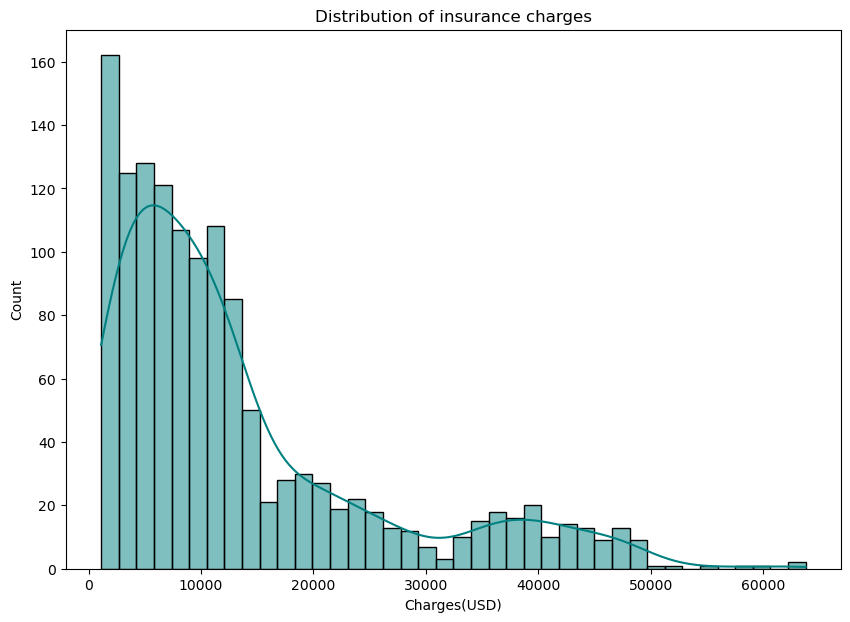

In [17]:
plt.figure(figsize=(10,7))
sns.histplot(data['charges'],bins=40,kde=True,color='teal')
plt.xlabel('Charges(USD)')
plt.ylabel('Count')
plt.title('Distribution of insurance charges')
plt.show()

# Observation
- Most people pay low amounts of insurance

# Scatter Plot:Charges vs Age

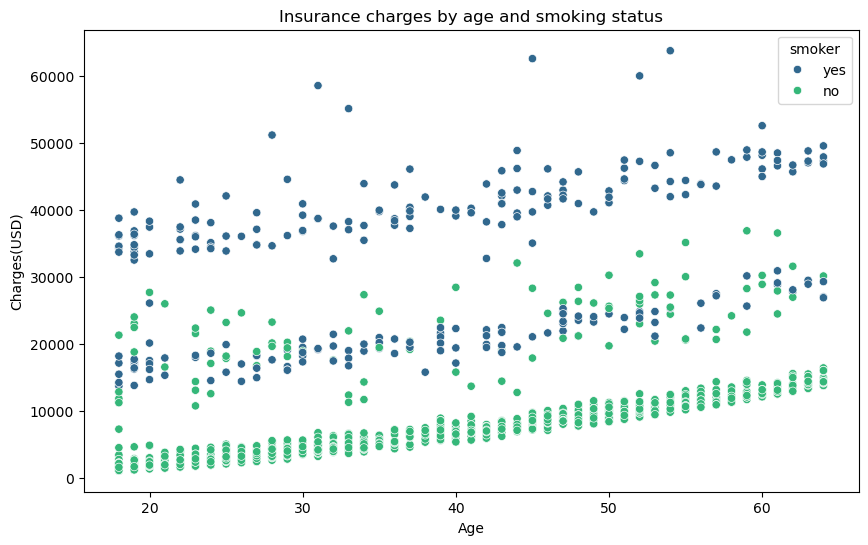

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=data,x='age',y='charges',palette='viridis',hue='smoker')
plt.xlabel('Age')
plt.ylabel('Charges(USD)')
plt.title('Insurance charges by age and smoking status')
plt.show()

# Observations
- Smokers:Charges much higher(20k-50k+),increase with age
- non-smokers:Charges between (3k-30k),also increases with age

# Boxplot: charges by smoker status

C:\Users\HP\AppData\Local\Temp\ipykernel_28904\3463250354.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data,x='smoker',y='charges',palette='magma')


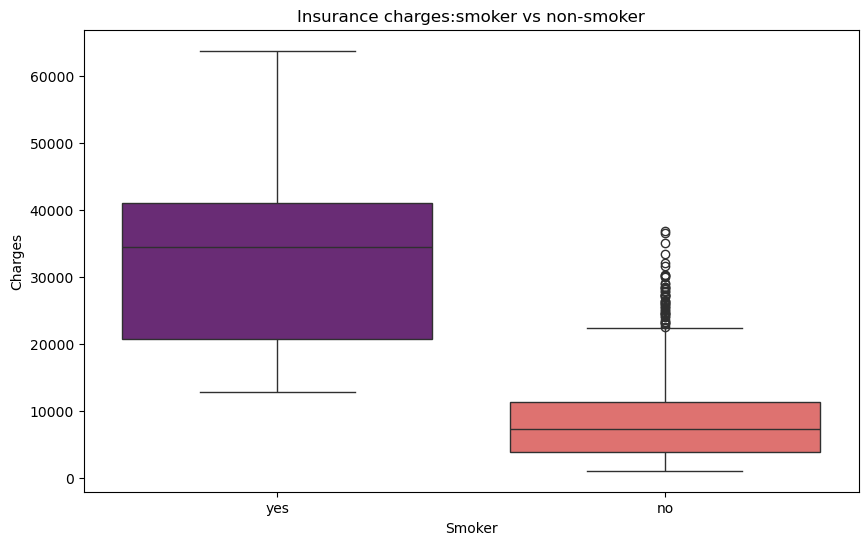

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data,x='smoker',y='charges',palette='magma')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.title('Insurance charges:smoker vs non-smoker')
plt.show()

In [20]:
# Average charges by smoker
print('Average charges by smoker status')
print(data.groupby('smoker')['charges'].mean().round(0))


Average charges by smoker status
smoker
no      8434.0
yes    32050.0
Name: charges, dtype: float64


# observation
- Smokers pay more on average than non-smokers

# 4.Linear Regression model
We will:
- Turn categorical columns(sex,smoker,region) into numbers using get_dummies
- Split data into train and test
- Train Linear Regression
- See how good the model is using RMSE
- Look the most important feature

In [21]:
# Turn categorical columns(sex,smoker,region) into numbers 
df=data.copy()
df=pd.get_dummies(df,columns=['sex','smoker','region'],drop_first=True)
print(df.columns.tolist())

['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


In [22]:
# Choose x(features)and y(Target)
x=df.drop('charges',axis=1)
y=df['charges']
print('shape of features(x):',x.shape)
print('shape of features(y):',y.shape)



shape of features(x): (1338, 8)
shape of features(y): (1338,)


In [23]:
# Split data into trin and test 
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [25]:
# Create and train the model
model=LinearRegression()
# Train the model using training data
# model.fit(x_train,y_train)
model.fit(x_train, y_train)     # ← correct (uppercase X)

LinearRegression()

In [26]:
# Make predictions on test data
y_pred=model.predict(x_test)
# Calculate error
from sklearn import metrics
import numpy as np
rmse=np.sqrt(metrics.mean_squared_error(y_test,y_pred))
print(f"RMSE = ${rmse:,.0f}")


RMSE = $5,796


In [27]:
# Which features matter most?
importance=pd.DataFrame({
    'Feature':x.columns,
    'coefficient':model.coef_
}).round(0)
importance=importance.sort_values('coefficient',ascending=False)
print('Features sorted by importance')
print(importance)

Features sorted by importance
            Feature  coefficient
4        smoker_yes      23651.0
2          children        425.0
1               bmi        337.0
0               age        257.0
3          sex_male        -19.0
5  region_northwest       -371.0
6  region_southeast       -658.0
7  region_southwest       -810.0


# observation
- smoker_yes has the highest coefficient,which means it increases the predicted insurance cost by $23651 when other things stay the same

# Conclusion
- smokers pay more per year on average (far more important than any other variable).
- Age, BMI and number of children have much smaller effects on insurance cost compared to smoking
- Region and sex barely influence the insurance charges in this dataset.